In [ ]:
from google.cloud import bigquery
client = bigquery.Client(project='hi780-494913')

In [ ]:

df = client.query("""
    SELECT *
    FROM `hi780-494913.hi780_project.features_10k`
    ORDER BY patient_id, admission_id, block_num
""").to_dataframe()

print(df.shape)

(63597, 85)


In [ ]:
# sql_engine: bigquery
# output_variable: df_count
# output_mode: table
# start _sql
_sql = """
SELECT COUNT(*) FROM `physionet-data.mimiciv_3_1_hosp.admissions`
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df_count = _bqsqlcell.run(_sql)
df_count

,f0_
0,546028


In [ ]:
# Cell above and this cell demonstrate how you can directly query the MIMIC databases and assign to dataframes

print(df_count.iat[0, 0])

546028


In [ ]:
#!pip install -q xgboost shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report
)

import xgboost as xgb
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [ ]:
print(f'Dataset shape: {df.shape}')
print(f'Unique patients: {df["patient_id"].nunique():,}')
print(f'Unique admissions: {df["admission_id"].nunique():,}')
print(f'Total blocks: {len(df):,}')
print()
print('Label distribution:')
print(df['label_vent_next_12h'].value_counts())
print(f'Positive rate: {df["label_vent_next_12h"].mean()*100:.2f}%')
print()
print('Top 20 most-missing columns (% NULL):')
print((df.isnull().mean() * 100).sort_values(ascending=False).head(20).round(1))

Dataset shape: (63597, 85)
Unique patients: 6,141
Unique admissions: 6,406
Total blocks: 63,597

Label distribution:
label_vent_next_12h
0    62417
1     1180
Name: count, dtype: Int64
Positive rate: 1.86%

Top 20 most-missing columns (% NULL):
bnp_mean     98.7
tnt_mean     97.1
pco2_mean    96.3
po2_mean     96.3
ph_mean      95.7
bmi_max      53.0
sbp_max      43.9
dbp_max      43.9
sbp_min      43.9
dbp_min      43.9
wbc_mean     26.6
hgb_mean     26.2
gluc_mean    26.0
na_mean      25.4
k_mean       25.1
cr_mean      25.0
gluc_low     21.4
bnp_high     21.4
gluc_high    21.4
hgb_low      21.4
dtype: float64


In [ ]:
ID_COLS = ['patient_id', 'admission_id', 'block_num']
LABEL_COL = 'label_vent_next_12h'
CATEGORICAL_COLS = ['gender', 'race_rollup']

# Sparse labs John flagged for missingness indicators
SPARSE_LAB_COLS = [c for c in ['bnp_mean', 'troponin_mean', 'pco2_mean', 'ph_mean', 'po2_mean']
                   if c in df.columns]
print(f'Sparse labs getting missingness flags: {SPARSE_LAB_COLS}')

data = df.copy()

# Missingness indicators BEFORE imputing
for col in SPARSE_LAB_COLS:
    data[f'{col}_missing'] = data[col].isnull().astype(int)

# One-hot encode categoricals
data = pd.get_dummies(data, columns=CATEGORICAL_COLS, drop_first=False)

# Convert bool columns to int
bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)

# Median-impute remaining NaNs
feature_cols = [c for c in data.columns if c not in ID_COLS + [LABEL_COL]]
data[feature_cols] = data[feature_cols].fillna(data[feature_cols].median(numeric_only=True))

print(f'Shape after preprocessing: {data.shape}')
print(f'Final feature count: {len(feature_cols)}')
print(f'NaNs remaining: {data[feature_cols].isnull().sum().sum()}')

Sparse labs getting missingness flags: ['bnp_mean', 'pco2_mean', 'ph_mean', 'po2_mean']
Shape after preprocessing: (63597, 97)
Final feature count: 93
NaNs remaining: 0


In [ ]:
X = data[feature_cols].values
y = data[LABEL_COL].values
groups = data['patient_id'].values

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

# Confirm no patient leakage
train_patients = set(groups[train_idx])
test_patients = set(groups[test_idx])
print(f'Train rows: {len(X_train):,} | Test rows: {len(X_test):,}')
print(f'Train patients: {len(train_patients):,} | Test patients: {len(test_patients):,}')
print(f'Patient overlap (must be 0): {len(train_patients & test_patients)}')
print(f'Train positive rate: {y_train.mean()*100:.2f}%')
print(f'Test positive rate: {y_test.mean()*100:.2f}%')

Train rows: 50,894 | Test rows: 12,703
Train patients: 4,912 | Test patients: 1,229
Patient overlap (must be 0): 0
Train positive rate: 1.86%
Test positive rate: 1.82%


In [ ]:
def evaluate_model(name, y_true, y_proba, threshold=0.5):
    """Compute AUROC, AUPRC, and threshold-based metrics."""
    auroc = roc_auc_score(y_true, y_proba)
    auprc = average_precision_score(y_true, y_proba)
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    print(f'\n=== {name} (threshold={threshold}) ===')
    print(f'AUROC:       {auroc:.4f}')
    print(f'AUPRC:       {auprc:.4f}')
    print(f'Sensitivity: {sensitivity:.4f}')
    print(f'Specificity: {specificity:.4f}')
    print(f'PPV:         {ppv:.4f}')
    print(f'NPV:         {npv:.4f}')
    print(f'Confusion matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}')

    return {
        'model': name, 'AUROC': auroc, 'AUPRC': auprc,
        'sensitivity': sensitivity, 'specificity': specificity,
        'PPV': ppv, 'NPV': npv, 'threshold': threshold
    }

results = []

In [ ]:
# Standardize features for LR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE,
    solver='liblinear'
)

# Cross-validation with GroupKFold on training data
gkf = GroupKFold(n_splits=5)
cv_aurocs = []
for fold, (tr, va) in enumerate(gkf.split(X_train_scaled, y_train, groups_train)):
    lr.fit(X_train_scaled[tr], y_train[tr])
    cv_aurocs.append(roc_auc_score(y_train[va], lr.predict_proba(X_train_scaled[va])[:, 1]))
print(f'LR 5-fold CV AUROC: {np.mean(cv_aurocs):.4f} (+/- {np.std(cv_aurocs):.4f})')

# Fit on full training set, evaluate on held-out test
lr.fit(X_train_scaled, y_train)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
results.append(evaluate_model('Logistic Regression', y_test, y_proba_lr))

LR 5-fold CV AUROC: 0.8228 (+/- 0.0112)

=== Logistic Regression (threshold=0.5) ===
AUROC:       0.8150
AUPRC:       0.1725
Sensitivity: 0.6494
Specificity: 0.8162
PPV:         0.0614
NPV:         0.9921
Confusion matrix: TN=10180, FP=2292, FN=81, TP=150


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

cv_aurocs = []
for fold, (tr, va) in enumerate(gkf.split(X_train, y_train, groups_train)):
    rf.fit(X_train[tr], y_train[tr])
    cv_aurocs.append(roc_auc_score(y_train[va], rf.predict_proba(X_train[va])[:, 1]))
print(f'RF 5-fold CV AUROC: {np.mean(cv_aurocs):.4f} (+/- {np.std(cv_aurocs):.4f})')

rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
results.append(evaluate_model('Random Forest', y_test, y_proba_rf))

RF 5-fold CV AUROC: 0.8490 (+/- 0.0095)

=== Random Forest (threshold=0.5) ===
AUROC:       0.8403
AUPRC:       0.2241
Sensitivity: 0.4329
Specificity: 0.9469
PPV:         0.1312
NPV:         0.9890
Confusion matrix: TN=11810, FP=662, FN=131, TP=100


In [ ]:
# scale_pos_weight = (negatives / positives) — handles imbalance
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {neg_pos_ratio:.2f}')

xgb_clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=neg_pos_ratio,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv_aurocs = []
for fold, (tr, va) in enumerate(gkf.split(X_train, y_train, groups_train)):
    xgb_clf.fit(X_train[tr], y_train[tr])
    cv_aurocs.append(roc_auc_score(y_train[va], xgb_clf.predict_proba(X_train[va])[:, 1]))
print(f'XGBoost 5-fold CV AUROC: {np.mean(cv_aurocs):.4f} (+/- {np.std(cv_aurocs):.4f})')

xgb_clf.fit(X_train, y_train)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
results.append(evaluate_model('XGBoost', y_test, y_proba_xgb))

scale_pos_weight: 52.63
XGBoost 5-fold CV AUROC: 0.7857 (+/- 0.0063)

=== XGBoost (threshold=0.5) ===
AUROC:       0.7886
AUPRC:       0.2071
Sensitivity: 0.4069
Specificity: 0.9427
PPV:         0.1162
NPV:         0.9885
Confusion matrix: TN=11757, FP=715, FN=137, TP=94



=== Model Comparison (test set, threshold=0.5) ===
                      AUROC   AUPRC  sensitivity  specificity     PPV     NPV  \
model                                                                           
Logistic Regression  0.8150  0.1725       0.6494       0.8162  0.0614  0.9921   
Random Forest        0.8403  0.2241       0.4329       0.9469  0.1312  0.9890   
XGBoost              0.7886  0.2071       0.4069       0.9427  0.1162  0.9885   

                     threshold  
model                           
Logistic Regression        0.5  
Random Forest              0.5  
XGBoost                    0.5  


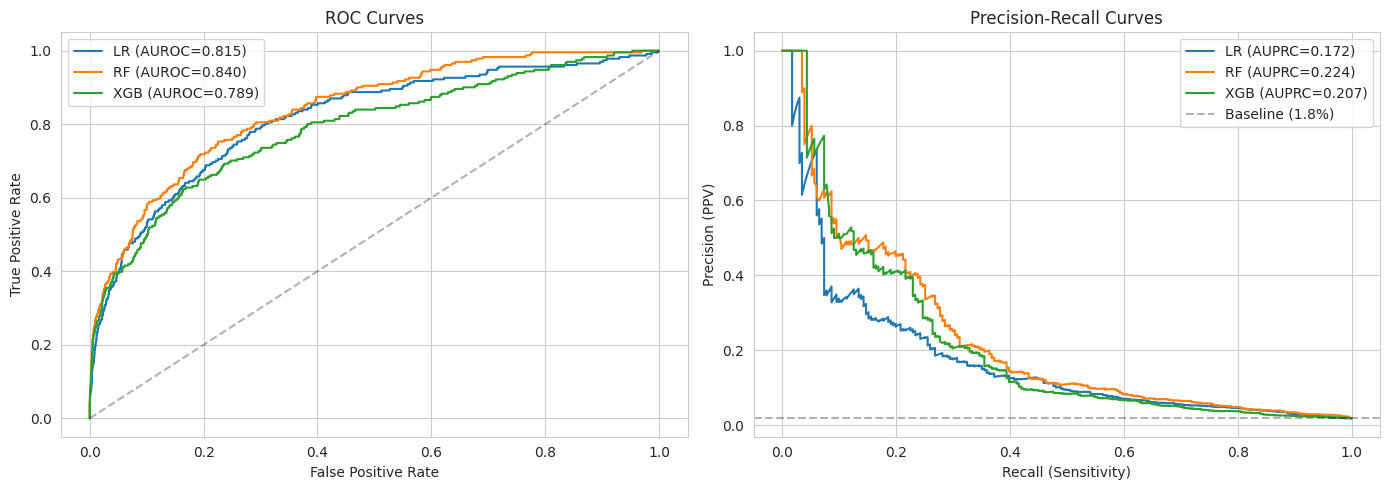

In [ ]:
results_df = pd.DataFrame(results).set_index('model')
print('\n=== Model Comparison (test set, threshold=0.5) ===')
print(results_df.round(4))

# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, y_proba in [('LR', y_proba_lr), ('RF', y_proba_rf), ('XGB', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auroc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUROC={auroc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

for name, y_proba in [('LR', y_proba_lr), ('RF', y_proba_rf), ('XGB', y_proba_xgb)]:
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    auprc = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, label=f'{name} (AUPRC={auprc:.3f})')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.3,
                label=f'Baseline ({y_test.mean()*100:.1f}%)')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

=== Top 20 LR coefficients (by absolute value) ===
                                       feature  coefficient
                              bnp_mean_missing     0.715255
                             pco2_mean_missing    -0.702156
                                      bnp_high     0.693213
                                 nutrition_npo     0.489358
                                  unit_surgery     0.469942
                              po2_mean_missing     0.342086
                       radiology_chest_imaging     0.241522
                                      diuretic    -0.223104
                               unit_cardiology     0.219167
                       culture_positive_device    -0.215023
                                bronchodilator     0.213396
race_rollup_Native Hawaiian / Pacific Islander    -0.198526
                                    antifungal     0.184468
                                     admit_age     0.162013
                                   unit_trauma   

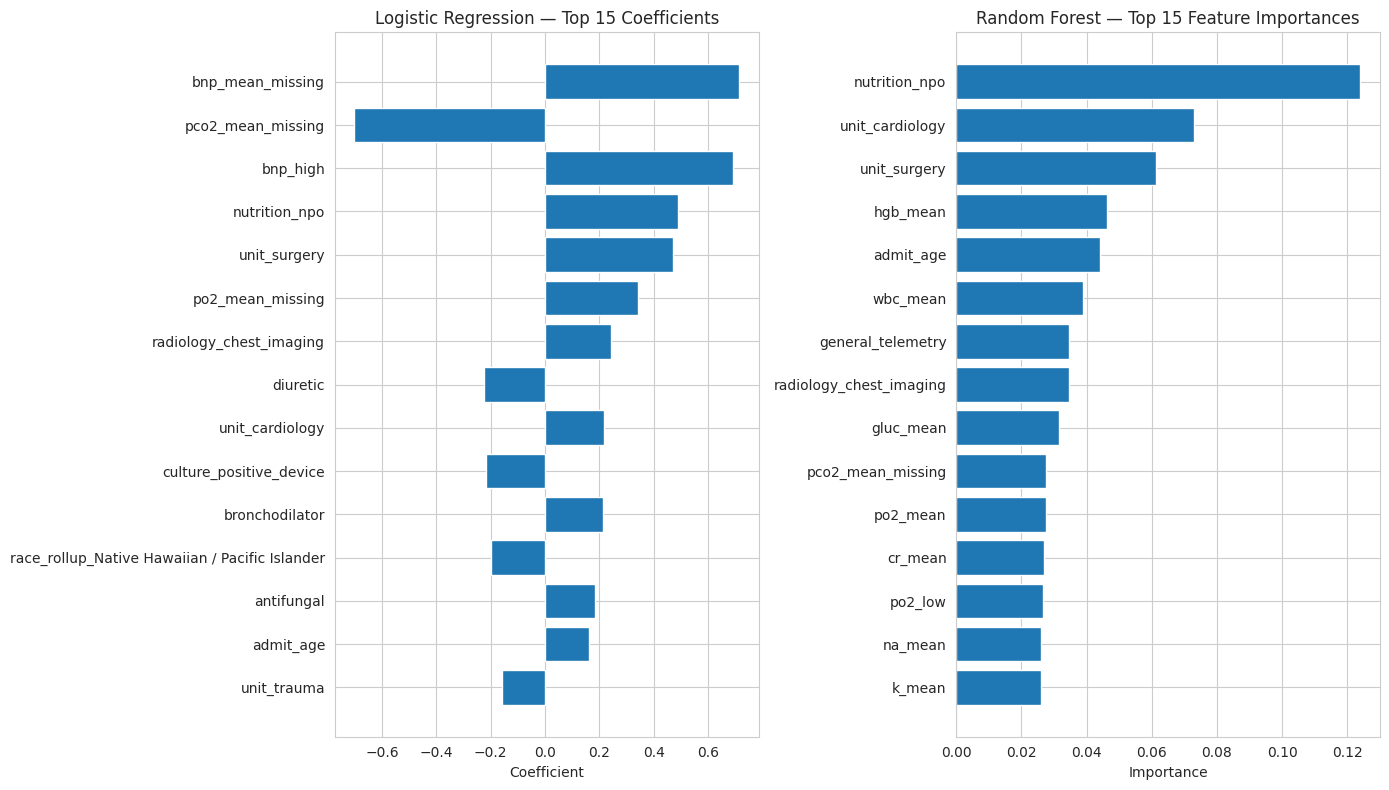

In [ ]:
# Logistic Regression coefficients
lr_coefs = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0]
}).assign(abs_coef=lambda d: d['coefficient'].abs()).sort_values('abs_coef', ascending=False)

print('=== Top 20 LR coefficients (by absolute value) ===')
print(lr_coefs[['feature', 'coefficient']].head(20).to_string(index=False))

# Random Forest importance
rf_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print('\n=== Top 20 RF feature importances ===')
print(rf_imp.head(20).to_string(index=False))

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
top_lr = lr_coefs.head(15)
axes[0].barh(top_lr['feature'][::-1], top_lr['coefficient'][::-1])
axes[0].set_title('Logistic Regression — Top 15 Coefficients')
axes[0].set_xlabel('Coefficient')

top_rf = rf_imp.head(15)
axes[1].barh(top_rf['feature'][::-1], top_rf['importance'][::-1])
axes[1].set_title('Random Forest — Top 15 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

/tmp/ipykernel_150/7764939.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, feature_names=feature_cols, max_display=20)


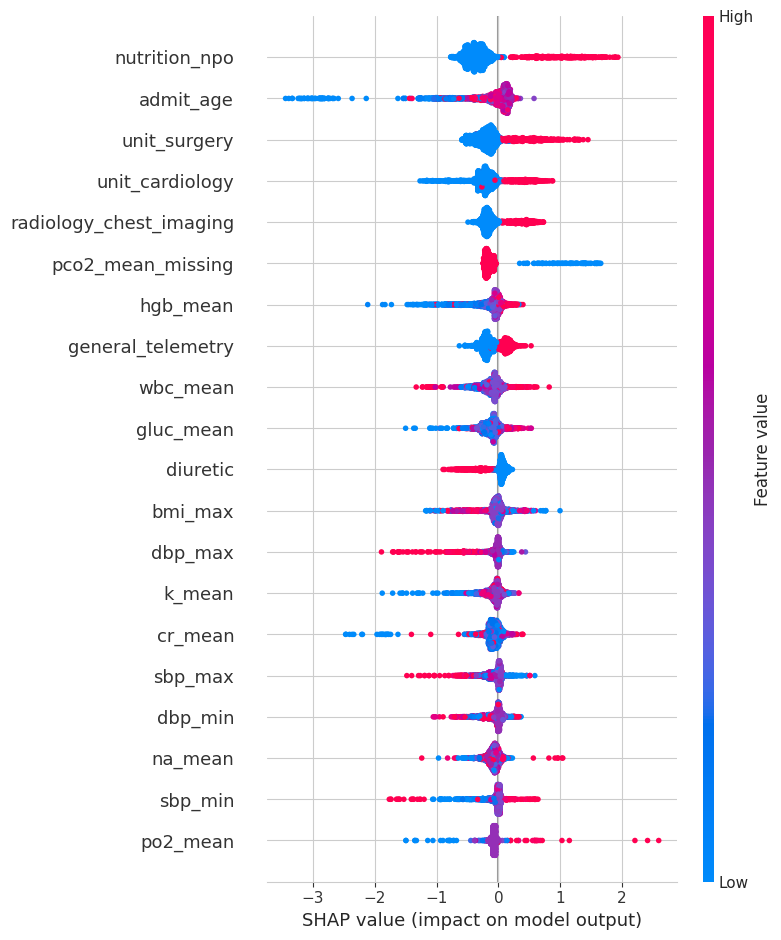

In [ ]:
# Sample test set to keep SHAP fast (full set can be slow)
sample_size = min(2000, len(X_test))
sample_idx = np.random.choice(len(X_test), sample_size, replace=False)
X_test_sample = X_test[sample_idx]

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot — top features
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_cols, max_display=20)

In [ ]:
# Best XGBoost is usually our top model — tune its threshold for sensitivity ≥ 0.80
prec, rec, thresholds = precision_recall_curve(y_test, y_proba_xgb)

# Find threshold giving sensitivity (recall) ≈ 0.80
target_sens = 0.80
valid = rec[:-1] >= target_sens  # exclude last point (threshold undefined)
if valid.any():
    chosen_idx = np.where(valid)[0][-1]  # highest threshold meeting target
    chosen_threshold = thresholds[chosen_idx]
    print(f'Threshold for sensitivity >= {target_sens}: {chosen_threshold:.4f}')
    evaluate_model('XGBoost (tuned threshold)', y_test, y_proba_xgb, threshold=chosen_threshold)
else:
    print('Could not achieve target sensitivity at any threshold.')

Threshold for sensitivity >= 0.8: 0.1122

=== XGBoost (tuned threshold) (threshold=0.11219091713428497) ===
AUROC:       0.7886
AUPRC:       0.2071
Sensitivity: 0.8009
Specificity: 0.6174
PPV:         0.0373
NPV:         0.9941
Confusion matrix: TN=7700, FP=4772, FN=46, TP=185


=== Calibration Metrics (test set) ===
Model                      Brier Score   ECE (10-bin)
-----------------------------------------------------
Logistic Regression             0.1416         0.2956
Random Forest                   0.0750         0.2193
XGBoost                         0.0566         0.1311


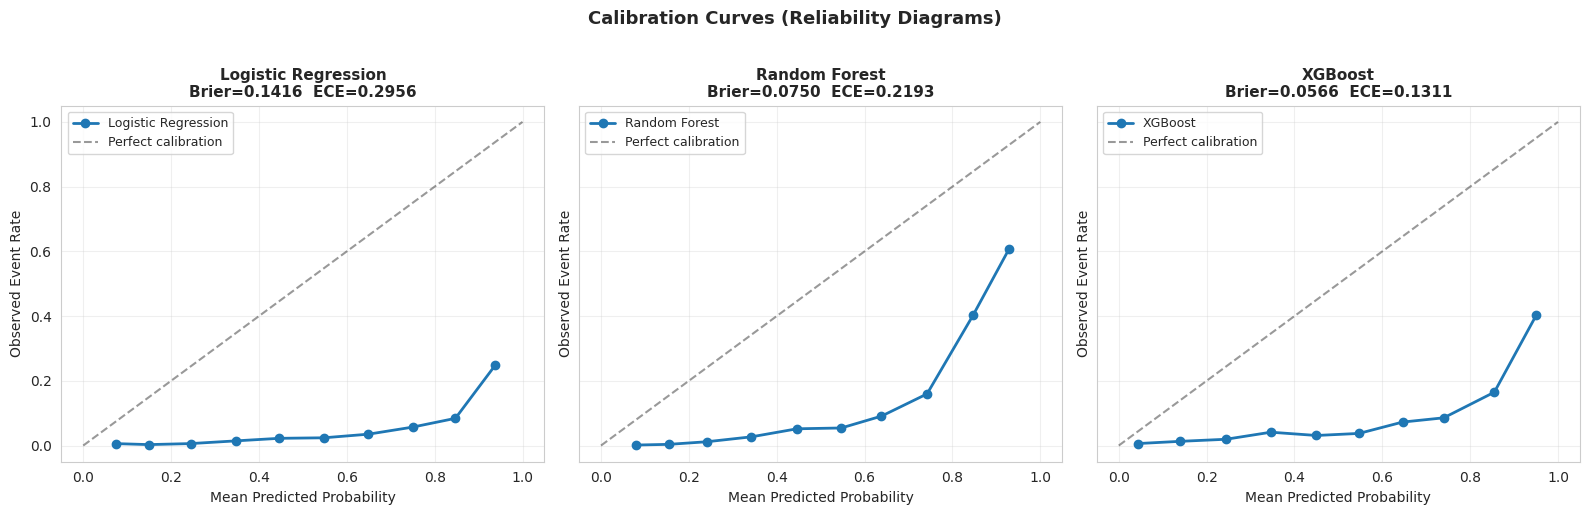

Saved: figure4_calibration.png


In [ ]:
## Calibration

# ============================================================
# CALIBRATION ANALYSIS — Reliability Diagrams, Brier Score, ECE
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def expected_calibration_error(y_true, y_proba, n_bins=10):
    """Compute Expected Calibration Error (ECE)."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        mask = (y_proba >= bin_edges[i]) & (y_proba < bin_edges[i + 1])
        if mask.sum() == 0:
            continue
        bin_acc = y_true[mask].mean()        # observed event rate in bin
        bin_conf = y_proba[mask].mean()      # mean predicted probability in bin
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return ece

models = [
    ('Logistic Regression', y_proba_lr),
    ('Random Forest',       y_proba_rf),
    ('XGBoost',             y_proba_xgb),
]

# --- Print scalar metrics ---
print('=== Calibration Metrics (test set) ===')
print(f'{"Model":<25} {"Brier Score":>12} {"ECE (10-bin)":>14}')
print('-' * 53)
for name, y_proba in models:
    bs  = brier_score_loss(y_test, y_proba)
    ece = expected_calibration_error(y_test, y_proba)
    print(f'{name:<25} {bs:>12.4f} {ece:>14.4f}')

# --- Reliability diagrams ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (name, y_proba) in zip(axes, models):
    frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac_pos, 'o-', label=name, linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
    bs  = brier_score_loss(y_test, y_proba)
    ece = expected_calibration_error(y_test, y_proba)
    ax.set_title(f'{name}\nBrier={bs:.4f}  ECE={ece:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability', fontsize=10)
    ax.set_ylabel('Observed Event Rate', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Calibration Curves (Reliability Diagrams)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure4_calibration.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figure4_calibration.png')